In [ ]:
import pandas as pd
import os
import requests
import json

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

In [ ]:
from preprocessing_utils import preprocess_NVD_data

In [ ]:
data_path = 'data'
if not os.path.exists(data_path):
    os.makedirs(data_path)

# EPSS data

Download the EPSS data from https://www.first.org/epss/data_stats into `data` folder

### <font color='blue'><b><i>TODO</i></b></font>:
- in the following cell, replace `epss_scores-2025-09-30.csv.gz` with the correct updated file (`epss_scores-2025-10-01.csv.gz`)

In [ ]:
epss_current = pd.read_csv(os.path.join(data_path, 'epss_scores-2025-10-01.csv.gz'), compression='gzip', header=1)
epss_current # a Python statement with a variable name at the end of a cell will display its contents below


,cve,epss,percentile
0,CVE-1999-0001,0.01141,0.77780
1,CVE-1999-0002,0.10742,0.93087
2,CVE-1999-0003,0.90362,0.99589
3,CVE-1999-0004,0.03215,0.86596
4,CVE-1999-0005,0.25334,0.96035
...,...,...,...
296328,CVE-2025-9994,0.00060,0.19138
296329,CVE-2025-9996,0.00179,0.40027
296330,CVE-2025-9997,0.00182,0.40386
296331,CVE-2025-9998,0.00023,0.04753


# NVD data

In [ ]:
base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
date_start_NVD = '2025-09-01T00:00:00.000Z' # Do NOT change these dates
date_end_NVD   = '2025-10-01T00:00:00.000Z' # Do NOT change these dates
start_index = 0
results_per_page = 1000
total_results = 1

all_cves = []

while start_index < total_results:
    params = {
        "pubStartDate": date_start_NVD,
        "pubEndDate": date_end_NVD,
        "resultsPerPage": results_per_page,
        "startIndex": start_index,
        "noRejected": ""
    }
    response = requests.get(base_url, params=params, timeout=6)
    if response.status_code != 200:
        print("Error:", response.status_code)
        break

    data = response.json()
    total_results = data.get("totalResults", 0)

    all_cves.extend(data.get("vulnerabilities", []))

    start_index += results_per_page
    print(start_index)



1000
2000
3000
4000
5000


In [ ]:
# normalize and preprocess data
df = pd.json_normalize(all_cves, record_path=None, sep='.', max_level=None)
df = preprocess_NVD_data(df)

# remove vulnerabilities marked as "reject" or "reserved"
df = df[(df['cve.vulnStatus']!='Reserved') & (df['cve.vulnStatus']!='Reject')]

# merge NVD and EPSS data
df = df.merge(epss_current, left_on="cve.id", right_on="cve", how="left")

In [ ]:
# save nvd data
with open(os.path.join(data_path, "nvd_cves.json"), "w", encoding="utf-8") as f:
    json.dump(all_cves, f, indent=2)

# save the final dataframe
df.to_csv(os.path.join(data_path, "vuln_2025_09.csv"))

# Exploratory Data Analysis

- display some examples (e.g., the first two CVE records)

In [ ]:
df.head(2).T

,0,1
cve.id,CVE-2025-9751,CVE-2025-9752
cve.sourceIdentifier,cna@vuldb.com,cna@vuldb.com
cve.published,2025-09-01 00:15:34.580000,2025-09-01 01:15:46.817000
cve.lastModified,2026-04-29 01:00:01.613000,2026-04-29 01:00:01.613000
cve.vulnStatus,Analyzed,Analyzed
cve.references,[{'url': 'https://github.com/HAO-RAY/HCR-CVE/i...,[{'url': 'https://github.com/i-Corner/cve/issu...
cve.cisaExploitAdd,NaN,NaN
cve.cisaActionDue,NaN,NaN
cve.cisaRequiredAction,NaN,NaN
cve.cisaVulnerabilityName,NaN,NaN


- show a bar plot with the daily volume of published CVEs

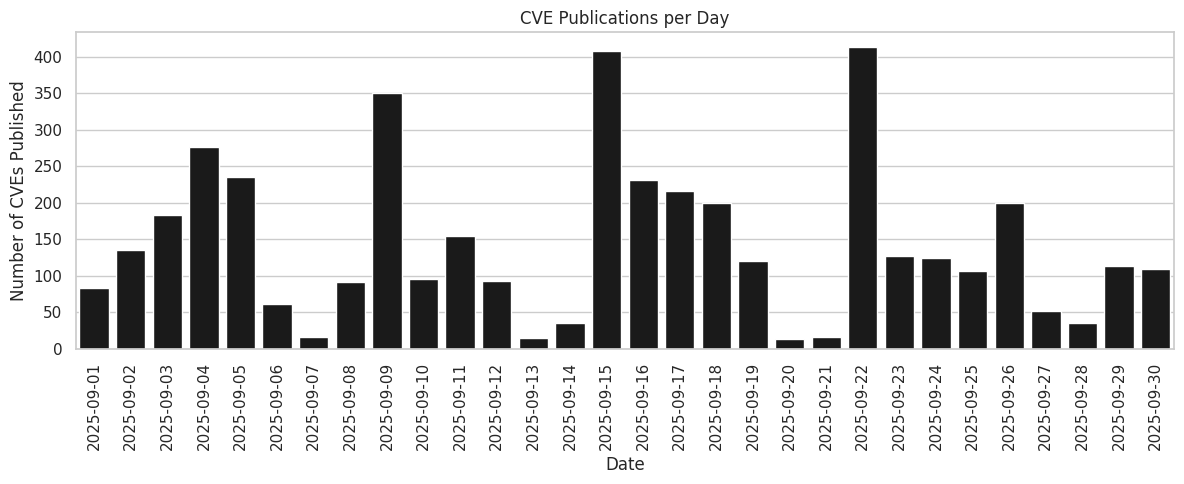

In [ ]:
published_counts = df["cve.published"].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=published_counts.index, y=published_counts.values, color="k" )
plt.xticks(rotation=90)
plt.xlabel("Date")
plt.ylabel("Number of CVEs Published")
plt.title("CVE Publications per Day")
plt.tight_layout()
plt.show()

- print the description of the last ten published vulnerabilities

In [ ]:
for idx, x in enumerate(df.sort_values('cve.published', ascending=False)[:10].iterrows()):
    print('-'*100)
    print(x[1]['cve.id'], x[1]['cve.published'])
    print(x[1].description)


----------------------------------------------------------------------------------------------------
CVE-2025-61792 2025-09-30 23:15:29.700000
Quadient DS-700 iQ devices through 2025-09-30 might have a race condition during the quick clicking of (in order) the Question Mark button, the Help Button, the About button, and the Help Button, leading to a transition out of kiosk mode into local administrative access. NOTE: the reporter indicates that the "behavior was observed sporadically" during "limited time on the client site," making it not "possible to gain more information about the specific kiosk mode crashing issue," and the only conclusion was "there appears to be some form of race condition." Accordingly, there can be doubt that a reproducible cybersecurity vulnerability was identified; sporadic software crashes can also be caused by a hardware fault on a single device (for example, transient RAM errors). The reporter also describes a variety of other issues, including initial acc

### <font color='blue'><b><i>TODO</i></b>: produce plots or tables to address the folowing points</font>
- what is the percentage of CVEs which received a CVSS score?
- report descriptive statistics of CVSS the CVSS base score and/or show its distribution
- report descriptive statistics of EPSS and/or show its distribution
- produce a scatter plot showing CVSS vs EPSS
- <b>be creative</b>!
    - How many vulnerabilities are published on CISA KEV?
    - What are the the 20 most frequent vendors? (vendor name can be extracted from the `vulnerable_cpes` field).
    - What are the 20 most frequent CWEs?
    - Anaything else you see fit!

<font color='blue'>Use text cells to discuss the outcome after each point</font>

## Calculate Percentage of CVEs with CVSS Score




To calculate the percentage of CVEs with a CVSS score, we need to count the non-null values in the 'cvss_baseScore' column, get the total number of CVEs, and then perform the percentage calculation.



In [ ]:
total_cves = len(df)
non_null_cvss_scores = df['cvss_baseScore'].count()
percentage_with_cvss = (non_null_cvss_scores / total_cves) * 100

print(f"Total CVEs: {total_cves}")
print(f"CVEs with CVSS Score: {non_null_cvss_scores}")
print(f"Percentage of CVEs with a CVSS score: {percentage_with_cvss:.2f}%")

Total CVEs: 4320
CVEs with CVSS Score: 4160
Percentage of CVEs with a CVSS score: 96.30%


In [ ]:
cvss_description = df['cvss_baseScore'].describe()
print("Descriptive statistics for CVSS Base Score:")
print(cvss_description)

median_cvss = df['cvss_baseScore'].median()
print(f"\nMedian CVSS Score: {median_cvss}")

Descriptive statistics for CVSS Base Score:
count    4160.000000
mean        6.770986
std         1.715107
min         2.200000
25%         5.500000
50%         6.500000
75%         7.800000
max        10.000000
Name: cvss_baseScore, dtype: float64

Median CVSS Score: 6.5


The descriptive statistics for the CVSS Base Score show the following:
- **Count**: There are 4160 CVEs with a CVSS base score, as seen previously.
- The **Mean (6.77)** and **Median (6.5)** are quite close, suggesting a relatively balanced distribution of severity, though it leans toward the 'Medium' to 'High' range.
- **Standard Deviation**: The standard deviation is about 1.72, suggesting a moderate spread in the scores.
- With **Max** of 10.0 and the **75th percentile** at 7.8, at least 25% of the vulnerabilities in this dataset are considered high or critical severity.

## EPSS Statistics

In [ ]:
epss_description = df['epss'].describe()
print("Descriptive Statistics for EPSS Score:")
print(epss_description)

Descriptive Statistics for EPSS Score:
count    4320.000000
mean        0.001477
std         0.017289
min         0.000020
25%         0.000240
50%         0.000320
75%         0.000470
max         0.810640
Name: epss, dtype: float64


The descriptive statistics for the EPSS Score show the following:
- **Count**: There are 4320 CVEs with an EPSS score, indicating that all merged CVEs have an EPSS score.
- **Mean**: The average EPSS score is very low, approximately 0.001477 (or 0.1477%), suggesting that the majority of vulnerabilities have a very low probability of being exploited.

- **Max**: The maximum EPSS score is 0.810640 (or 81.064%), indicating that there are a few vulnerabilities with a very high probability of being exploited.

These statistics highlight that EPSS scores are heavily skewed towards the lower end, with most CVEs having a very low predicted probability of exploitation, but a few have a significantly higher score.

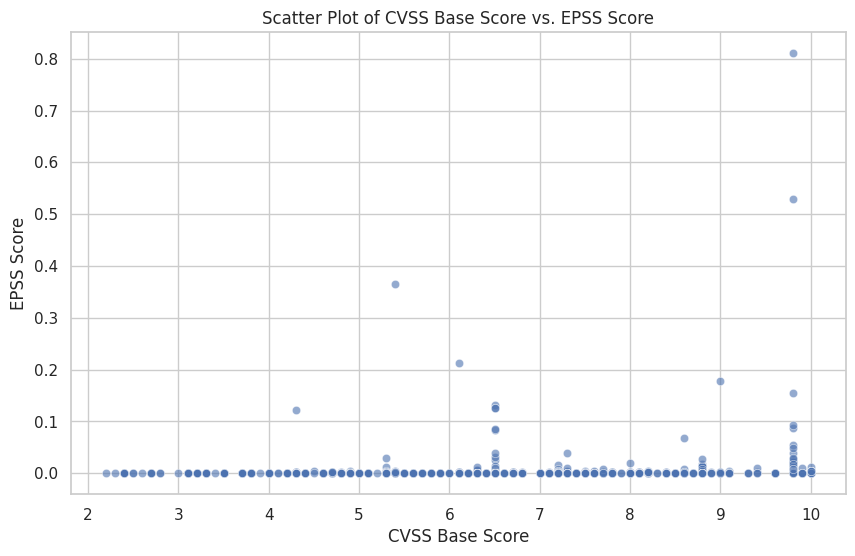

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cvss_baseScore', y='epss', alpha=0.6)
plt.title('Scatter Plot of CVSS Base Score vs. EPSS Score')
plt.xlabel('CVSS Base Score')
plt.ylabel('EPSS Score')
plt.show()

##Insights from the Plot:
  - **EPSS Provides Additional Context to CVSS**: The plot clearly illustrates that CVSS alone is not a perfect predictor of exploitability. Many CVEs with high CVSS scores have very low EPSS scores, meaning they are severe in theory but unlikely to be exploited in practice. Conversely, some CVEs with moderate CVSS scores might still have elevated EPSS scores, indicating they are more likely to be exploited than their CVSS score alone would suggest.
  
  - **Prioritization Strategy**: This visualization supports a risk-based prioritization strategy. Organizations should focus on vulnerabilities that have both a high CVSS Base Score and a high EPSS Score. These represent both high severity and high exploitability. CVEs with high CVSS but low EPSS might be less urgent to patch immediately.

##The number of vulnerabilities published on the CISA KEV



In [ ]:
num_cisa_kev = df['cve.cisaExploitAdd'].count()
print(f"Number of vulnerabilities published on CISA KEV: {num_cisa_kev}")

Number of vulnerabilities published on CISA KEV: 15


## What are the the 20 most frequent vendors?



In [ ]:
# extract the vendor name from a CPE string
def extract_vendor(cpe_string):
    if pd.isna(cpe_string) or not isinstance(cpe_string, str):
        return None
    parts = cpe_string.split(':')
    if len(parts) > 3:
        return parts[3]
    return None

In [ ]:
all_vendors = []
# iterating through each list of CPEs in the column.
for cpe_list in df['vulnerable_cpes']:
    if isinstance(cpe_list, list):
        # extracting the vendor for each CPE.
        for cpe_string in cpe_list:
            vendor = extract_vendor(cpe_string)
            if vendor:
                all_vendors.append(vendor)

print(f"Extracted {len(all_vendors)} vendors from the 'vulnerable_cpes' column.")

Extracted 18491 vendors from the 'vulnerable_cpes' column.


In [ ]:
vendor_counts = pd.Series(all_vendors).value_counts()
top_20_vendors = vendor_counts.head(20)

print("Top 20 Most Frequent Vendors:")
print(top_20_vendors)

Top 20 Most Frequent Vendors:
linux        4259
liferay      3007
qualcomm     2385
samsung      1759
cisco        1636
microsoft    1044
google        410
ivanti        369
adobe         253
apple         231
ibm           227
esri          180
dell          147
debian        139
gitlab         96
vasion         82
campcodes      73
autodesk       67
wso2           66
foxit          65
Name: count, dtype: int64


## What are the 20 most frequent CWEs?



In [ ]:
all_cwes = []
for cwe_list in df['cwe_list']:
    if isinstance(cwe_list, list):
        for cwe_id in cwe_list:
            all_cwes.append(cwe_id)

cwe_counts = pd.Series(all_cwes).value_counts()
top_20_cwes = cwe_counts.head(20)

print("Top 20 Most Frequent CWEs:")
print(top_20_cwes)

Top 20 Most Frequent CWEs:
CWE-79     718
CWE-89     434
CWE-74     294
CWE-476    247
CWE-401    216
CWE-862    203
CWE-416    174
CWE-352    162
CWE-94     134
CWE-125    126
CWE-284    121
CWE-787    113
CWE-77     101
CWE-78      90
CWE-434     89
CWE-918     76
CWE-22      73
CWE-20      67
CWE-200     66
CWE-362     65
Name: count, dtype: int64


- The most common weakness enumeration is `CWE-79` (Improper Neutralization of Input During Web Page Generation) with **718** occurrences, followed by `CWE-89` (SQL Injection) with **434** occurrences, suggesting prevalent web application security flaws.

# CVE selection


### <font color='blue'><b><i>TODO</i></b>
- Filter the CVEs with low EPSS (<1%)
- Select candidate CVEs
    - From the resulting subset, select 10 CVEs that you think will reach high EPSS by the end of the course.
    - Clearly describe the criteria you used for selection (e.g., high CVSS, popular software, CWE, popular vendor, number of references, keyword in description, manual inspection, random sampling, security blogs).
- Share the selected CVE ids with the instructor (by two weeks). Use the code cell below to produce the csv file to submit.
- Track the EPSS of your CVEs over time


In [ ]:
# We filter the CVEs that have EPSS < 1%
low_epss_cves = df[df['epss'] < 0.01].copy()

## Selection Criteria

The selection logic used for picking the 10 CVEs involved a multi-criteria approach based on a calculated composite_score. This score prioritizes CVEs that are listed in CISA KEV, are associated with top 20 vendors, and/or top 20 Common Weakness Enumerations (CWEs), while also considering their CVSS base score.

In [ ]:
# We assign numerical weights for the different criteria
CISA_KEV_WEIGHT = 100
TOP_VENDOR_WEIGHT = 10
TOP_CWE_WEIGHT = 10
CVSS_SCORE_WEIGHT = 1

In [ ]:
# We introduce new column to indicate whether the CVE is included in CISA KEV or not.
low_epss_cves['is_cisa_kev'] = low_epss_cves['cve.cisaExploitAdd'].notna().astype(int)

# We check for every CVE whether the vendor is among the top 20 vendor list or not.
top_vendors_list = top_20_vendors.index.tolist()
def check_top_vendor(cpe_list, top_vendors_list):
    if isinstance(cpe_list, list):
        for cpe_string in cpe_list:
            vendor = extract_vendor(cpe_string)
            if vendor and vendor in top_vendors_list:
                return 1
    return 0
low_epss_cves['is_top_vendor'] = low_epss_cves['vulnerable_cpes'].apply(lambda x: check_top_vendor(x, top_vendors_list))

# We check for every CVE whether it is associated with a top CWE or not.
top_cwes_list = top_20_cwes.index.tolist()
def check_top_cwe(cwe_list, top_cwes_list):
    if isinstance(cwe_list, list):
        for cwe_id in cwe_list:
            if cwe_id in top_cwes_list:
                return 1
    return 0
low_epss_cves['is_top_cwe'] = low_epss_cves['cwe_list'].apply(lambda x: check_top_cwe(x, top_cwes_list))

# Handling missing values in the 'cvss_baseScore' column by filling any NaN values with 0.
low_epss_cves['cvss_baseScore'] = low_epss_cves['cvss_baseScore'].fillna(0)

# Calculating the composite_score for each CVE using the defined weights.
low_epss_cves['composite_score'] = (
    CISA_KEV_WEIGHT * low_epss_cves['is_cisa_kev'] +
    TOP_VENDOR_WEIGHT * low_epss_cves['is_top_vendor'] +
    TOP_CWE_WEIGHT * low_epss_cves['is_top_cwe'] +
    CVSS_SCORE_WEIGHT * low_epss_cves['cvss_baseScore']
)

# Sorting the DataFrame based on the combined selection score and cvss_baseScore (descending).
sorted_cves = low_epss_cves.sort_values(by=['composite_score', 'cvss_baseScore'], ascending=[False, False])

# Selecting the top 10 CVE that best fit the different criteria.
selected_cve_ids_refined = sorted_cves.head(10)['cve.id'].tolist()

print(f"Selected 10 CVE IDs: {selected_cve_ids_refined}")
print(sorted_cves.head(10))

Selected 10 CVE IDs: ['CVE-2025-21042', 'CVE-2025-21043', 'CVE-2025-54236', 'CVE-2025-48543', 'CVE-2025-20362', 'CVE-2025-9242', 'CVE-2025-48703', 'CVE-2025-41244', 'CVE-2025-20352', 'CVE-2025-26399']
              cve.id                  cve.sourceIdentifier  \
1717  CVE-2025-21042           mobile.security@samsung.com   
1718  CVE-2025-21043           mobile.security@samsung.com   
1163  CVE-2025-54236                       psirt@adobe.com   
641   CVE-2025-48543                  security@android.com   
3754  CVE-2025-20362                       psirt@cisco.com   
2497   CVE-2025-9242  5d1c2695-1a31-4499-88ae-e847036fd7e3   
2967  CVE-2025-48703                         cve@mitre.org   
4135  CVE-2025-41244                   security@vmware.com   
3663  CVE-2025-20352                       psirt@cisco.com   
3475  CVE-2025-26399                  psirt@solarwinds.com   

               cve.published        cve.lastModified cve.vulnStatus  \
1717 2025-09-12 08:15:44.743 2025-11-12 14:32

In [ ]:
nickname = 'Abdelrahman_Alaaeldin' # TODO: put your nickname here

# TODO: put your selected IDs here
selected = ['CVE-2025-21042',
            'CVE-2025-21043',
            'CVE-2025-54236',
            'CVE-2025-48543',
            'CVE-2025-20362',
            'CVE-2025-9242',
            'CVE-2025-48703',
            'CVE-2025-41244',
            'CVE-2025-20352',
            'CVE-2025-26399']

df[df['cve.id'].isin(selected)].to_csv(os.path.join(data_path, f'{nickname}.csv'))

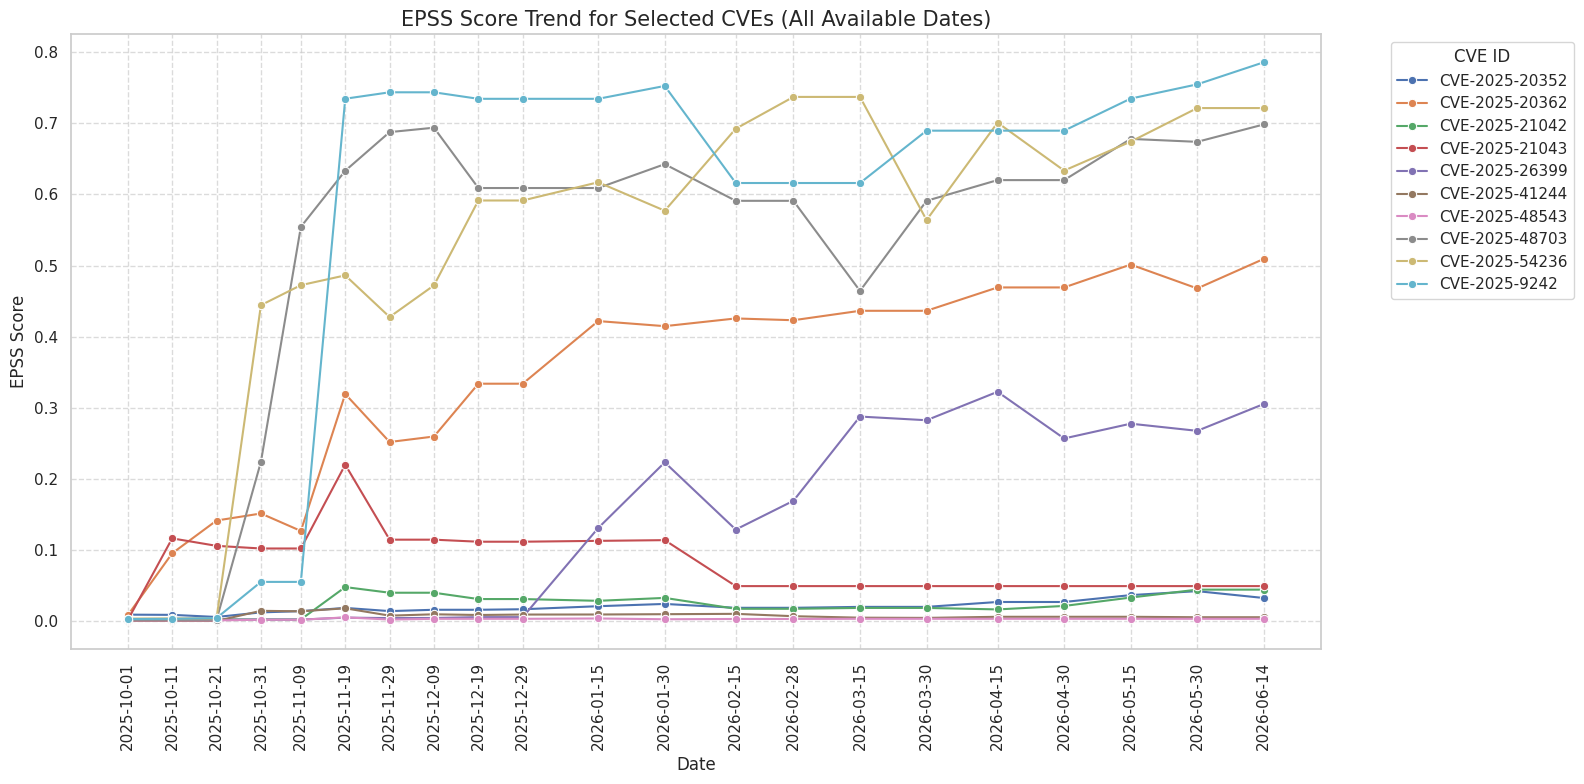

Latest EPSS scores for selected CVEs:


,cve,epss,percentile,date
279520,CVE-2025-20352,0.03236,0.87413,2026-06-14
279530,CVE-2025-20362,0.50936,0.97935,2026-06-14
279911,CVE-2025-21042,0.04412,0.89306,2026-06-14
279912,CVE-2025-21043,0.04908,0.89872,2026-06-14
284223,CVE-2025-26399,0.30526,0.96837,2026-06-14
294087,CVE-2025-41244,0.00529,0.67718,2026-06-14
297400,CVE-2025-48543,0.00310,0.54749,2026-06-14
297510,CVE-2025-48703,0.69849,0.98694,2026-06-14
301549,CVE-2025-54236,0.72152,0.98779,2026-06-14
314602,CVE-2025-9242,0.78594,0.99068,2026-06-14


In [ ]:
import re
import glob

# 1. Identify all EPSS files and extract dates
file_pattern = os.path.join(data_path, 'epss_scores-*.csv.gz')
files = sorted(glob.glob(file_pattern))

data_list = []

for file_path in files:
    # Extract date from filename (e.g., '2025-10-01')
    date_match = re.search(r'(\d{4}-\d{2}-\d{2})', os.path.basename(file_path))
    if date_match:
        file_date = date_match.group(1)
        # Read file
        temp_df = pd.read_csv(file_path, compression='gzip', header=1)
        # Filter for our selected 10 CVEs
        filtered = temp_df[temp_df['cve'].isin(selected_cve_ids_refined)].copy()
        filtered['date'] = pd.to_datetime(file_date)
        data_list.append(filtered)

# 2. Combine data
trend_df = pd.concat(data_list)

# 3. Visualization
plt.figure(figsize=(16, 8))
sns.lineplot(data=trend_df, x='date', y='epss', hue='cve', marker='o')

# Set x-ticks to show every date present in the dataset
unique_dates = sorted(trend_df['date'].unique())
plt.xticks(unique_dates, [d.strftime('%Y-%m-%d') for d in unique_dates], rotation=90)

plt.title('EPSS Score Trend for Selected CVEs (All Available Dates)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('EPSS Score', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='CVE ID')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Display the latest scores for reference
print("Latest EPSS scores for selected CVEs:")
display(trend_df[trend_df['date'] == trend_df['date'].max()][['cve', 'epss', 'percentile', 'date']])